In [1]:
import matplotlib.pyplot as plt
import PcmPy as pcm
import numpy as np
import os
import pandas as pd
from pathlib import Path
import sys

ROOT =  Path().resolve().parent
sys.path.append(str(ROOT))

import globals.globals as gl

plt.style.use('default')

Base directory found: /cifs/diedrichsen/data/SensoriMotorPrediction/
Base directory: /cifs/diedrichsen/data/SensoriMotorPrediction/
Atlases dir found: /home/UWO/memanue5/Documents/GitHub/data/atlases


In [2]:
experiment = 'smp2'
H = 'L'

# Representation geometry in force patterns before perturbation onset (Fig. 5a)

force: tval=3.2540805843915543, pval=0.0031393634018095596


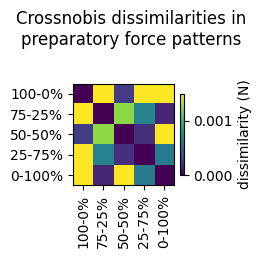

In [15]:
from vis import plot_dissimilarities

fig, ax = plt.subplots(figsize=(2.5, 2.5), constrained_layout=True)

vmin, vmax = 0, .0015

G = np.load(os.path.join(gl.baseDir, experiment, gl.pcmDir, 'G_obs.force.plan.npy'))
Df = pcm.G_to_dist(G)
fig, ax = plot_dissimilarities(fig, ax, None, Df, list(gl.regressor_mapping.keys())[:5], vmin=vmin, vmax=vmax, sqrt=False, source='force')
cax = ax.get_images()[0]
cbar = fig.colorbar(cax, ax=ax, orientation='vertical', fraction=.04)
cbar.set_label('dissimilarity (N)')

fig.suptitle('Crossnobis dissimilarities in\npreparatory force patterns')

plt.show()

# Mean force difference between cued and uncued finger during preparation

In [5]:
filepath = os.path.join(gl.baseDir, experiment, gl.behavDir, f'behaviour.trial.tsv')
dat = pd.read_csv(filepath, sep='\t', )
dat = dat[(dat['cue']=='0-100%') | (dat['cue']=='0-100%')]
dat = dat.groupby(['sn']).mean(numeric_only=True).reset_index()
print('--- AVERAGE FORCE DIFFERENCE BETWEEN CUED AND UNCUED---')
print(f'{dat.forceDiff.mean()}+/-{dat.forceDiff.std() / np.sqrt(len(dat.sn.unique()))}')


--- AVERAGE FORCE DIFFERENCE BETWEEN CUED AND UNCUED---
0.05000936861742333+/-0.02505079810941822


# Linear regression between BOLD and force mean dissimilarity (Fig. 5b)


M1
slope: -2.0298247794658746, p = 0.667
intercept: 0.02730904885174715, p_intercept = 0.002
R2 = 0.016

S1
slope: -0.7745984342968869, p = 0.871
intercept: 0.03708242174301418, p_intercept = 0.000
R2 = 0.002


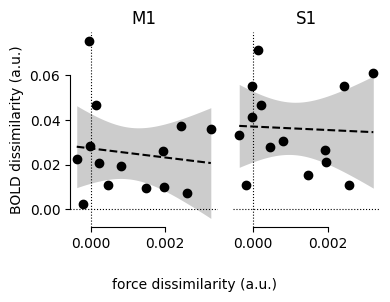

In [6]:
from vis import plot_correlation

rois_tmp = ['M1', 'S1']

fig, axs = plt.subplots(1, len(rois_tmp), sharex=True, sharey=True, figsize=(4, 3))

x = Df.mean(axis=(1, 2))

for r, roi in enumerate(rois_tmp):
    print(f'\n{roi}')
    G = np.load(os.path.join(ROOT, 'sensori-motor-prediction', 'data', 'encoding',f'G_obs.plan.glm12.{H}.{roi}.npy'))
    D = np.array([pcm.G_to_dist(Gg) for Gg in G])
    y = D.mean(axis=(1, 2))
    fig, axs =  plot_correlation(fig, axs, r, x, y, alternative_slope='two-sided', alternative_intercept='two-sided')
    axs[r].set_title(roi)

for ax in axs:
    yticks = ax.get_yticks()
    xticks = ax.get_xticks()
    ax.spines['left'].set_bounds(yticks[1], yticks[-2])
    ax.spines['bottom'].set_bounds(xticks[1], xticks[-2])

axs[0].set_ylabel('BOLD dissimilarity (a.u.)', fontsize=10)
axs[1].tick_params('y', left=False)
fig.supxlabel('force dissimilarity (a.u.)', fontsize=10)

fig.tight_layout()

plt.show()